In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyaxions import jaxions as pa
import importlib

import matplotlib as mpl
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = True

In [2]:
importlib.reload(pa)

<module 'pyaxions.jaxions' from '/Users/madomaxo/Salsa/jaxions/jaxions/scripts/pyaxions/jaxions.py'>

# Sim created with 

ic.dat 

mpirun -np 1 kini --wDz 0.1 --fA 1e11

In [28]:
# read files (2 spectra each)
mf_ = pa.fm('/Users/madomaxo/Salsa/jaxions/develop/kini/out/')
modemask = pa.gml(mf_,'modes/ctheta?')
mf = mf_[modemask]

Excluded corrupted file in /Users/madomaxo/Salsa/jaxions/develop/kini/out//: /Users/madomaxo/Salsa/jaxions/develop/kini/out/m/axion.m.00985


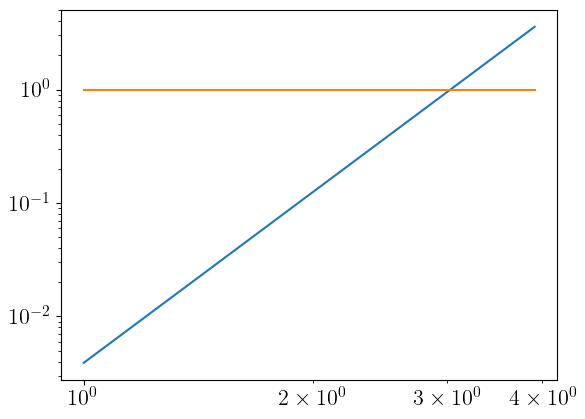

In [29]:
ft = pa.gml(mf_,'ftype')
plt.loglog(pa.gml(mf_,'ct'),pa.gml(mf_,'massA')*pa.gml(mf_,'R')*pa.gml(mf_,'delta'))
plt.plot(pa.gml(mf_,'ct'),ft=='Axion')
plt.plot(pa.gml(mf_,'ct'),ft=='Paxion')

# Linear

In [30]:
t = pa.gml(mf,'ct')                     # ctime
M = pa.gml(mf,'massA')*pa.gml(mf,'R')   # cmass
R = pa.gml(mf,'R')                      # scale factor
k = pa.gm(mf[0],'da/modes/k/data')      # k values [H1R1[
m = pa.gml(mf,'da/modes/ctheta/data')   # ctheta
v = pa.gml(mf,'da/modes/cvheta/data')   # ctheta'

nn = pa.gm(mf[0],'nmodelist')           # number of modes
print(t[0],t[-1])

1.0000881840143154 3.250034338953885


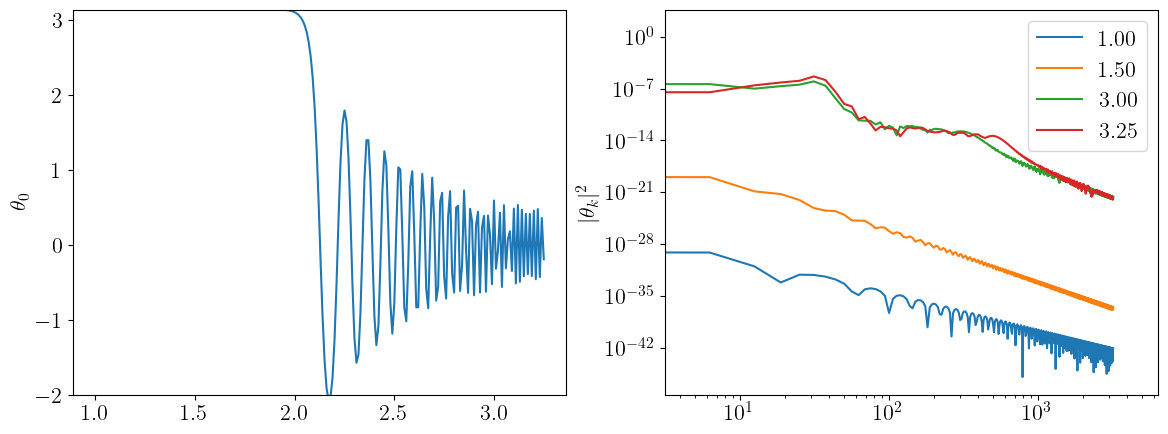

In [31]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
for ik in [0]:
    # compare evolution of zero mode with and without RHS (should be the same)
    q = ax[0].plot(t,(m[:,ik]/R)-(m[:,ik]/R)[-20:].mean())
    # ax[0].plot(t,m0[:,ik]/R,'--',c=q[0].get_color())
ax[0].set_ylim(-2,np.pi)

for time in [0,1.5,3.0,5.0]:

    i = np.argmin((t-time)**2)
    w = np.sqrt(k**2+M[i]**2)
    sp  = (m[i]**2+v[i]**2/w**2)/R[i]**2
    q = ax[1].loglog(k,sp,label='%.2f'%t[i])
ax[1].set_ylabel(r'$|\theta_k|^2$')    
ax[0].set_ylabel(r'$\theta_0$')    
ax[1].set_xlim(k[1]/2,k[-1]*2)
ax[1].legend()

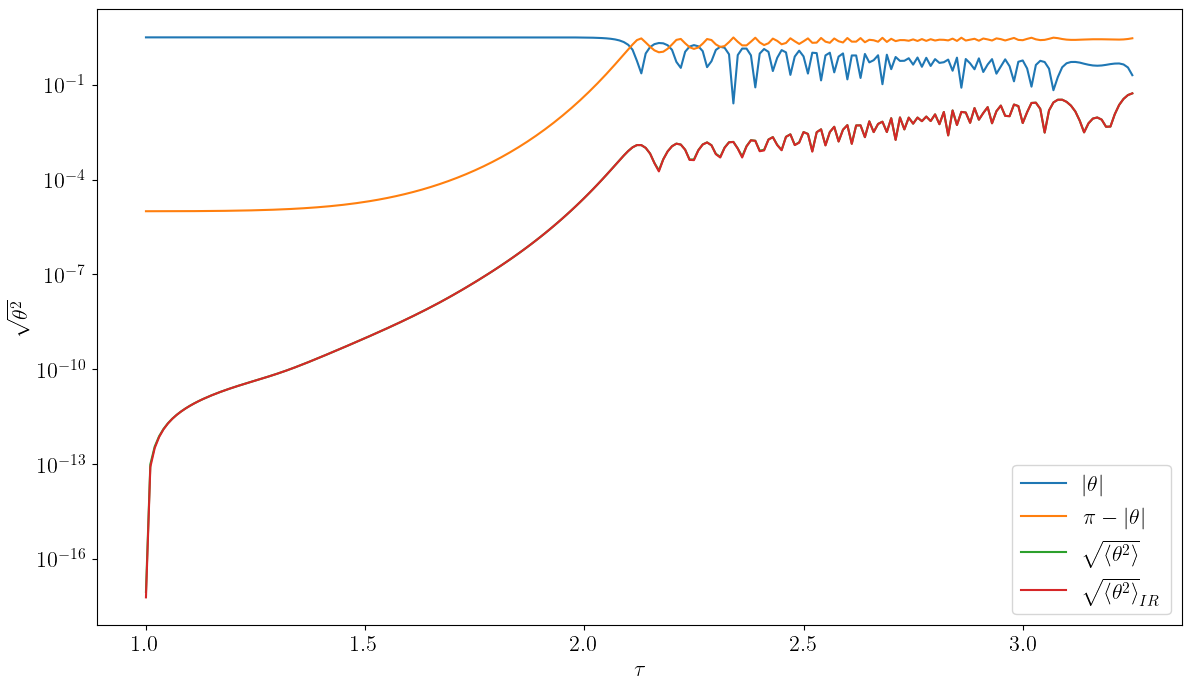

In [32]:
fig,ax=plt.subplots(1,figsize=(14,8))
ct = pa.gml(mf,'ct')
le = len(nn)
we  = (((m/R[:,np.newaxis])**2)[:,1:le]*nn[np.newaxis,1:]).sum(axis=1)
we_10  = (((m/R[:,np.newaxis])**2)[:,1:le]*nn[np.newaxis,1:])[:,:10].sum(axis=1)
# we0 = (((m0/R[:,np.newaxis])**2)[:,1:le]*nn[np.newaxis,1:]).sum(axis=1)
plt.plot(t,np.abs(m[:,ik]/R),label=r'$|\theta|$')
plt.plot(t,np.pi-np.abs(m[:,ik]/R),label=r'$\pi-|\theta|$')
# plt.semilogy(R,we0)
plt.semilogy(ct,np.sqrt(we),label=r'$\sqrt{\langle \theta^2\rangle}$')
plt.semilogy(ct,np.sqrt(we_10),label=r'$\sqrt{\langle \theta^2\rangle}_{IR}$')
# plt.semilogy(ct,np.sqrt(we0),label=r'$\sqrt{\langle \theta^2\rangle}_{\rm noRHS}$')

plt.ylabel(r"$\sqrt{\theta^2}$")
plt.xlabel(r"$\tau$")
plt.legend()

# Non - linear

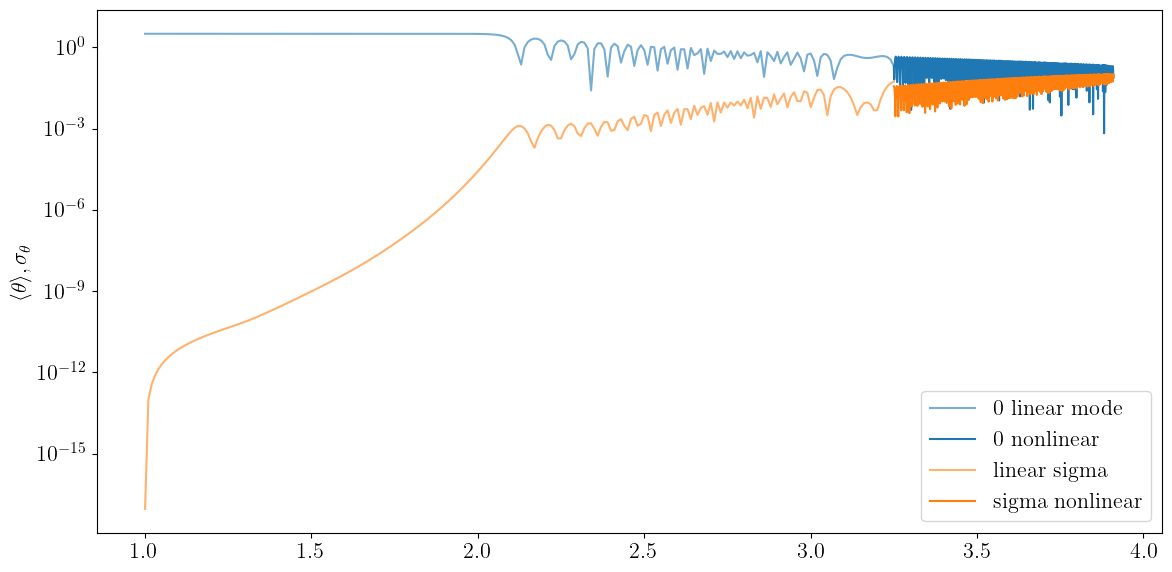

In [33]:
# Continue theta and sigma with the post-conversion 3D measurements
spatialmask = pa.gml(mf_, 'da/bins/thetaB/data?').astype(bool)
mf_spatial = np.asarray(mf_)[spatialmask]

def theta_moments(measurement):
    """Return mean(theta) and sigma(theta) from a thetaB histogram."""
    density = np.asarray(pa.gm(measurement, 'binthetaB'), dtype=float)
    theta = np.linspace(
        pa.gm(measurement, 'binthetaBmin'),
        pa.gm(measurement, 'binthetaBmax'),
        density.size,
    )
    norm = density.sum()
    mean = np.sum(density * theta) / norm
    variance = np.sum(density * (theta - mean)**2) / norm
    return mean, np.sqrt(max(variance, 0.0))

t_spatial = pa.gml(mf_spatial, 'ct')
moments_spatial = np.asarray([theta_moments(file) for file in mf_spatial])
theta_spatial = moments_spatial[:, 0]
sigma_spatial = moments_spatial[:, 1]

# Linear estimates: zero radial mode and the 3D-weighted nonzero modes.
theta_linear = m[:, 0] / R
sigma_linear = np.sqrt(we)

fig, ax = plt.subplots(1, figsize=(12, 6), sharex=True)
ax.plot(t, np.abs(theta_linear),'C0',label='0 linear mode',alpha=0.6)
ax.plot(t_spatial, np.abs(theta_spatial), 'C0',label='0 nonlinear')
ax.set_ylabel(r'$\langle\theta\rangle,\sigma_\theta$')
ax.legend()

ax.semilogy(t, sigma_linear, 'C1',label='linear sigma',alpha=0.6)
ax.semilogy(t_spatial, sigma_spatial, 'C1',label='sigma nonlinear')
# ax.set_ylabel(r'$\sigma_\theta$')
ax.legend()
plt.tight_layout()

3.250034338953885
-0.199840992670122 -0.33651416636704207 -0.1065670802793495
3.910160209730339
0.07796790063963711 -4.372870706778678 2.393878525633751


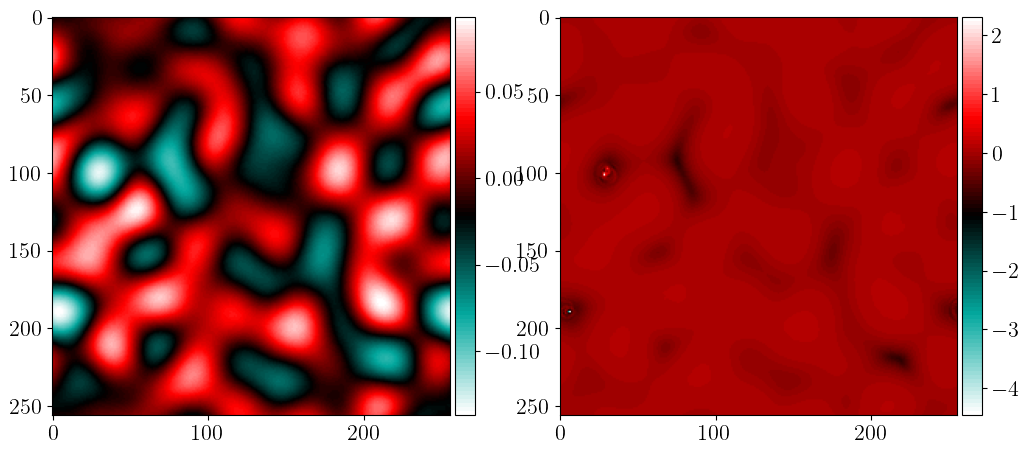

In [37]:
mf_3d = mf_[~modemask]
c=0
fig, ax = plt.subplots(1,2, figsize=(12, 6))
for it in [0,-1]:
    print(pa.gm(mf_3d[it],'ct'))
    th=pa.gm(mf_3d[it],'maptheta')
    print(th.mean(),th.min(),th.max())
    # af = ax[c].imshow(th,cmap=pa.thetacmap,vmin=-np.pi,vmax=np.pi)
    af = ax[c].imshow(th-th.mean(),cmap=pa.thetacmap)
    pa.colorbar(af)
    c = c+1

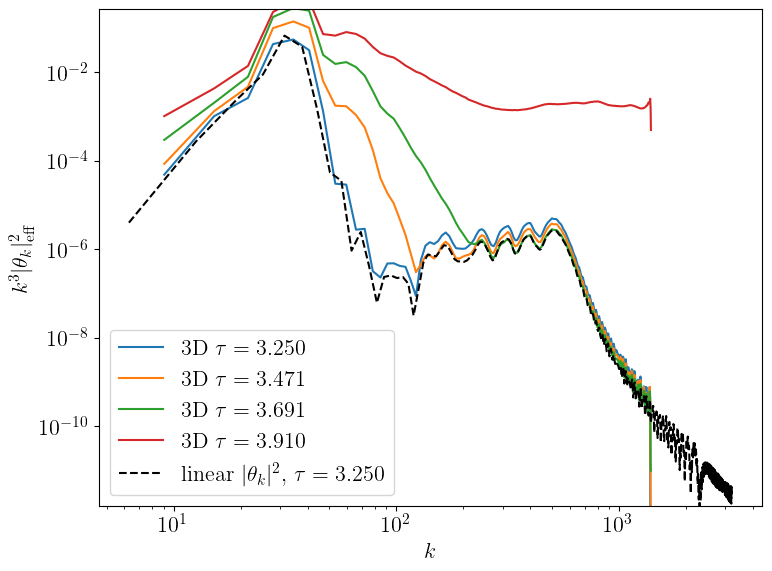

In [38]:
# Post-conversion 3D energy spectra, analogous to sp in the linear-mode plot
energy_mask = pa.gml(mf_3d, 'espK_0?').astype(bool)
mf_energy = np.asarray(mf_3d)[energy_mask]

if len(mf_energy) == 0:
    raise RuntimeError('No 3D energy spectra found; use --meas 65566 --spmask 1 --spKGV 7')

# The mode-count and average-k metadata are stored in the first linear file.
nn_energy = np.asarray(pa.gm(mf[0], 'nmodelist'))
avek_energy = np.asarray(pa.gm(mf[0], 'aveklist'))
k_energy = (2*np.pi/pa.gm(mf_energy[0], 'L')) * np.sqrt(
    np.divide(avek_energy, nn_energy, out=np.zeros_like(avek_energy), where=nn_energy > 0)
)
valid = (nn_energy > 0) & (k_energy > 0)

fig, ax = plt.subplots(1, figsize=(8, 6))
volume = pa.gm(mf_energy[0], 'L')**3
indices = np.unique(np.linspace(0, len(mf_energy)-1, min(4, len(mf_energy)), dtype=int))
for i in indices:
    f = mf_energy[i]
    eK = np.asarray(pa.gm(f, 'espK_0'))
    eG = np.asarray(pa.gm(f, 'espG_0'))
    eV = np.asarray(pa.gm(f, 'espV_0'))
    R_3d = pa.gm(f, 'R')
    M_3d = pa.gm(f, 'massA') * R_3d
    omega2_3d = k_energy**2 + M_3d**2
    denominator = volume * nn_energy * R_3d**2 * omega2_3d
    sp_3d = np.divide(
        2*(eK + eG + eV), denominator,
        out=np.zeros_like(eK), where=denominator > 0,
    )
    ax.loglog(k_energy[valid], k_energy[valid]**3 * sp_3d[valid], label=r'3D $\tau=%.3f$' % pa.gm(f, 'ct'))

# Exactly the same oscillator-amplitude convention for the final linear modes.
i_linear = -1
w_linear = np.sqrt(k**2 + M[i_linear]**2)
sp_linear = (m[i_linear]**2 + v[i_linear]**2/w_linear**2)/R[i_linear]**2
ax.loglog(
    k[1:], k[1:]**3 * sp_linear[1:]/2, 'k--', linewidth=1.5,
    label=r'linear $|\theta_k|^2$, $\tau=%.3f$' % t[i_linear],
)
ax.set_ylim((k**3*sp_linear)[1:].min()/2,(k**3*sp_linear)[1:].max()*2)
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$k^3 |\theta_k|^2_{\rm eff}$')
ax.legend()
plt.tight_layout()